In [20]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import  ncx2
import pandas as pd

In [22]:
class StochasticProcess:
    def __init__(self, params, T, Nx, Nt, init_state = None):
        self.params = params
        self.T = T
        self.Nx = Nx # Number of trajectories
        self.Nt = Nt # Number of discretization steps
        self.init_state = init_state

        #Wiener Process by default
        self.bxt = lambda x: 0
        self.sigmaxt = lambda x: 1
        self.bxt_x = lambda x: 0
        self.bxt_xx = lambda x: 0
        self.sigmaxt_x = lambda x: 0
        self.sigmaxt_xx = lambda x: 0

    def DefaultInitState(self):
        return np.zeros(self.Nx)

    def SampleFromDensity(self, x0, t, t0):
        result = np.zeros(self.Nx)
        for k in range(0, self.Nx):
            result[k] = x0[k] + np.random.normal(0, 1) * np.sqrt(t - t0)
        return result

    def PathGenerator(self):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = self.SampleFromDensity(x_data[i - 1], t_data[i], t_data[i - 1])
        return t_data, x_data

    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + dwt[i - 1]
        return t_data, x_data

    def EulerSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + self.bxt(x_data[i - 1]) * dt + self.sigmaxt(x_data[i - 1]) * dwt[i - 1]
        return t_data, x_data

    def Milstein1Solution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + self.bxt(x_data[i - 1]) * dt + self.sigmaxt(x_data[i - 1]) * dwt[i - 1] + \
                        1/2 * self.sigmaxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1]) * (dwt[i - 1]**2 - dt)
        return t_data, x_data

    def Milstein2Solution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + (self.bxt(x_data[i - 1]) - 1/2 * self.sigmaxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1])) * dt +\
                        self.sigmaxt(x_data[i - 1]) * dwt[i - 1] + 1/2 * self.sigmaxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1]) * dwt[i - 1]**2 +\
                        (1/2 * self.bxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1]) + 1/2 * self.bxt_x(x_data[i - 1]) * self.sigmaxt(x_data[i - 1]) +\
                        1/4 * self.sigmaxt(x_data[i - 1])**2 * self.sigmaxt_xx(x_data[i - 1])) * dt * dwt[i - 1] +\
                        (1/2 * self.bxt(x_data[i - 1]) * self.bxt_x(x_data[i - 1]) + 1/4 * self.bxt_xx(x_data[i - 1]) * self.sigmaxt(x_data[i - 1])**2) * dt**2
        return t_data, x_data

    def PredictorCorrectorSolution(self, dwt, eta = 1/2, alpha = 1/2):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            yw = x_data[i - 1] + self.bxt(x_data[i - 1]) * dt + self.sigmaxt(x_data[i - 1]) * dwt[i - 1]
            bwim1 = self.bxt(x_data[i - 1]) - eta * self.sigmaxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1])
            bwi = self.bxt(yw) - eta * self.sigmaxt(yw) * self.sigmaxt_x(yw)
            x_data[i] = x_data[i - 1] + alpha * bwi * dt + (1 - alpha) * bwim1 * dt +\
                        eta * self.sigmaxt(yw) * dwt[i - 1] + (1 - eta) * self.sigmaxt(x_data[i - 1]) * dwt[i - 1]
        return t_data, x_data
    
    
    

class OUprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta, mu, sigma]
        self.bxt = lambda x: self.params[0] * (self.params[1] - x)
        self.sigmaxt = lambda x: self.params[2]
        self.bxt_x = lambda x: -self.params[0]

    def DefaultInitState(self):
        return self.params[1] * np.ones(self.Nx)

    def StationaryState(self):
        theta = self.params[0]
        mu = self.params[1]
        sigma = self.params[2]

        result = np.zeros(self.Nx)

        for j in range(0, self.Nx):
            m = mu
            v = sigma**2 / (2 * theta)
            result[j] = np.random.normal(m, np.sqrt(v))
        return result

    def SampleFromDensity(self, x0, t, t0):
        theta = self.params[0]
        mu = self.params[1]
        sigma = self.params[2]

        result = np.zeros(self.Nx)

        for j in range(0, self.Nx):
            m = mu + (x0[j] - mu) * np.exp(-theta * (t - t0))
            v = sigma**2 / (2 * theta) * (1 - np.exp(-2 * theta * (t - t0)))
            result[j] = np.random.normal(m, np.sqrt(v))
        return result

    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        theta = self.params[0]
        mu = self.params[1]
        sigma = self.params[2]

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        Ito_integral_sum = np.zeros(self.Nx)
        Determinated_part = mu + (x_data[0] - mu) * np.exp(-theta * t_data)
        for i in range(1, self.Nt + 1):
            Ito_integral_sum += sigma * np.exp(theta * t_data[i - 1]) * dwt[i - 1]
            x_data[i] = Determinated_part[i] + Ito_integral_sum * np.exp(-theta * t_data[i])
        return t_data, x_data


class CIRprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta1, theta2, theta3]
        self.bxt = lambda x: self.params[0] - self.params[1] * x
        self.sigmaxt = lambda x: self.params[2] * np.sqrt(np.maximum(x, 0))
        self.bxt_x = lambda x: - self.params[1]
        self.sigmaxt_x = lambda x: self.params[2] * 1 / (2 * np.sqrt(np.maximum(x, 0)))
        self.sigmaxt_xx = lambda x: -self.params[2] * 1 / (4 * np.maximum(x, 0)**(1/4))

    def DefaultInitState(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)

    def StationaryState(self):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        result = np.zeros(self.Nx)

        for j in range(0, self.Nx):
            c = 2 * k / (sigma**2)
            u = 0
            q = 2 * k * theta / sigma**2 - 1
            result[j] = ncx2.rvs(2 * q + 2, 2 * u) / (2 * c)
        return result

    def SampleFromDensity(self, x0, t, t0):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        result = np.zeros(self.Nx)

        for j in range(0, self.Nx):
            c = 2 * k / (sigma**2 * (1 - np.exp(-k * (t - t0))))
            u = c * x0[j] * np.exp(-k * (t - t0))
            #v = c * x
            q = 2 * k * theta / sigma**2 - 1
            result[j] = ncx2.rvs(2 * q + 2, 2 * u) / (2 * c)
        return result

    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        Ito_integral_sum = np.zeros(self.Nx)
        Determinated_part = (x_data[0] - theta1 / theta2) * np.exp(-theta2 * t_data) + theta1/theta2
        for i in range(1, self.Nt + 1):
            Ito_integral_sum += theta3 * np.exp(theta2 * t_data[i - 1]) * np.sqrt(np.maximum(x_data[i - 1], 0)) * dwt[i - 1]
            x_data[i] = Determinated_part[i] + Ito_integral_sum * np.exp(-theta2 * t_data[i])
        return t_data, x_data


class BSMprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta1, theta2] or [r, sigma]
        self.bxt = lambda x: self.params[0] * x
        self.sigmaxt = lambda x: self.params[1] * x
        self.bxt_x = lambda x: self.params[0]
        self.sigmaxt_x = lambda x: self.params[1]

    def DefaultInitState(self):
        return np.ones(self.Nx)

    def SampleFromDensity(self, x0, t, t0):
        r = self.params[0]
        sigma = self.params[1]

        result = np.zeros(self.Nx)

        m = (r - 1/2 * sigma**2) * (t - t0)
        v = sigma**2 * (t - t0)

        for j in range(0, self.Nx):
            result[j] = x0[j] * np.random.lognormal(m, np.sqrt(v))
        return result

    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        r = self.params[0]
        sigma = self.params[1]

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] * np.exp((r - sigma**2 / 2) * dt + sigma * dwt[i - 1])
        return t_data, x_data
    


Еxercise  1. Suppose we have a   Brownian motion  defined by
 $$
 dX_t = \theta_1 X_tdt + \theta_2X_tdW_t, \quad X_0 = 1, \text{ with } (\theta_1, \theta_2) = (2, 0.5).
 $$
Compare approximations
*   the Euler approximation algorithm;
*   the 1st Milstein scheme;
*   the 2nd Milstein scheme;
*   the predictor-corrector method  (set default $\alpha = \eta = 1/2$);
*   KPS method

with the exact solution on $[0,1]$, levels of discretization $N=1024$.


Упражнение 1. Предположим, что броуновское движение задано:
$$
dX_t = \theta_1 X_tdt + \theta_2X_tdW_t, \quad X_0 = 1, \quad (\theta_1, \theta_2) = (2, 0.5).
$$
Сравните численные схемы
* алгоритм приближения Эйлера;
* 1-я схема Мильштейна;
* 2-я схема Мильштейна;
* метод предиктора-корректора (по умолчанию $\alpha = \eta = 1/2$);
* метод KPS

с точным решением на интервале $[0,1]$, для $N=1024$ точек.

In [5]:
T = 1
Nx = 1
Nt = 1024

x0 = 1
init_state = x0 * np.ones(Nx)

#theta = 2
#mu = 10
#sigma = 3.5
#params = [theta, mu, sigma]

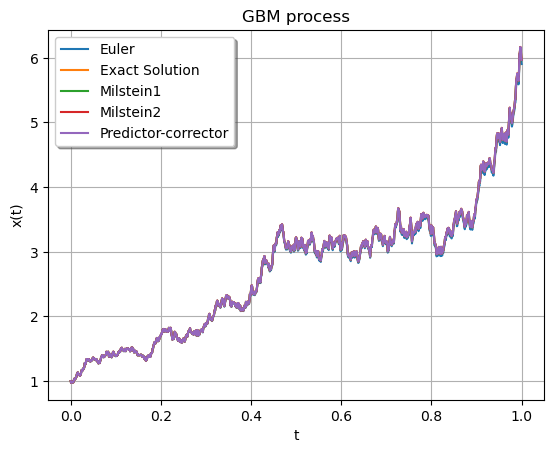

In [9]:
theta1 = 1
theta2 = 1/2
params = [theta1, theta2]

dwt = np.random.normal(0, 1, size = (Nt, Nx)) * np.sqrt(T/Nt)


BSMp = BSMprocess(params, T, Nx, Nt, init_state)
t_data, x_data = BSMp.EulerSolution(dwt)
plt.plot(t_data, x_data, label = 'Euler')

t_data, x_data = BSMp.ExactSolution(dwt)
plt.plot(t_data, x_data, label = 'Exact Solution')

t_data, x_data = BSMp.Milstein1Solution(dwt)
plt.plot(t_data, x_data, label = 'Milstein1')

t_data, x_data = BSMp.Milstein2Solution(dwt)
plt.plot(t_data, x_data, label = 'Milstein2')

t_data, x_data = BSMp.PredictorCorrectorSolution(dwt, 1/2, 1/2)
plt.plot(t_data, x_data, label = 'Predictor-corrector')

plt.title("GBM process")
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

Task. Compare the different approximations and the exact solution Brownian motion
for different levels of discretization
$$
N=\{2, 4, 8, 128, 256, 512, 1024, 8192, 16384, 32768\}
$$
being the number of subintervals of $[0,1]$.
As the result provide the table with maximum absolute difference.


In [13]:

theta1 = 1.0
theta2 = 0.5
params = [theta1, theta2]
T = 1.0
Nx = 1                  
init_state = np.array([1.0])
N_values = [2, 4, 8, 128, 256, 512, 1024, 8192, 16384, 32768]

np.random.seed(42)
N_max = max(N_values)
dW_fine = np.random.normal(0, 1, size=N_max) * np.sqrt(T / N_max)
W_fine = np.concatenate(([0.0], np.cumsum(dW_fine)))

results = []

for N in N_values:
    idx = np.linspace(0, N_max, N + 1, dtype=int)
    dwt = np.diff(W_fine[idx]).reshape(-1, Nx)
    
    # Инициализируем процесс GBM
    BSMp = BSMprocess(params, T, Nx, N, init_state)
    
    # Вычисляем решения
    t_ex, x_ex = BSMp.ExactSolution(dwt)
    t_eu, x_eu = BSMp.EulerSolution(dwt)
    t_mi1, x_mi1 = BSMp.Milstein1Solution(dwt)
    t_mi2, x_mi2 = BSMp.Milstein2Solution(dwt)
    t_pc, x_pc = BSMp.PredictorCorrectorSolution(dwt, 1/2, 1/2)
    
    # Максимальная абсолютная погрешность ||X_approx - X_exact||_∞
    err_eu  = np.max(np.abs(x_eu - x_ex))
    err_mi1 = np.max(np.abs(x_mi1 - x_ex))
    err_mi2 = np.max(np.abs(x_mi2 - x_ex))
    err_pc  = np.max(np.abs(x_pc - x_ex))
    
    results.append({
        'N': N, 
        'Euler': err_eu, 
        'Milstein1': err_mi1, 
        'Milstein2': err_mi2, 
        'Predictor-Corrector': err_pc
    })

# Формируем и выводим таблицу
df = pd.DataFrame(results)
print("\nМаксимальная абсолютная погрешность ||X_approx - X_exact||_∞")
print(df.to_string(index=False, float_format='%.6e'))


Максимальная абсолютная погрешность ||X_approx - X_exact||_∞
    N        Euler    Milstein1    Milstein2  Predictor-Corrector
    2 8.876077e-02 2.299810e-01 3.722002e-02         8.558797e-03
    4 4.891573e-02 1.656519e-01 1.945944e-02         3.625351e-03
    8 1.314266e-01 8.415715e-02 2.316539e-03         1.128861e-02
  128 2.639155e-02 9.020530e-03 1.309630e-03         6.181112e-04
  256 3.222933e-02 4.444608e-03 6.718172e-04         3.142130e-04
  512 1.018054e-02 2.207067e-03 3.058853e-04         2.098446e-04
 1024 1.990173e-02 1.200818e-03 7.344080e-05         1.685701e-04
 8192 5.434625e-03 1.666268e-04 3.189479e-05         4.734083e-05
16384 1.855700e-03 8.054393e-05 1.005788e-05         1.762796e-05
32768 1.325881e-03 3.732178e-05 1.321689e-06         4.418563e-06


Task. Conduct a study of the influence of the choice of values $\alpha$ and $\eta$ ​​on the accuracy of the  solution and plot a 3D graph where the x-axis is $α$'s values, y-axis is $\eta$'s values, and z-axis are maximum absolute difference between the exact solution and the predictor-corrector approximation.



In [ ]:
# your code

Task 2.  Repeat the Task 1 for the Cox-Ingersoll-Ross process
$$
dX_t = (\theta_1 - \theta_2X_t)dt + \theta_3 \sqrt{ X_t}dW_t, X_0 = 10, (\theta_1, \theta_2, \theta_3) = (6, 3, 2).
$$

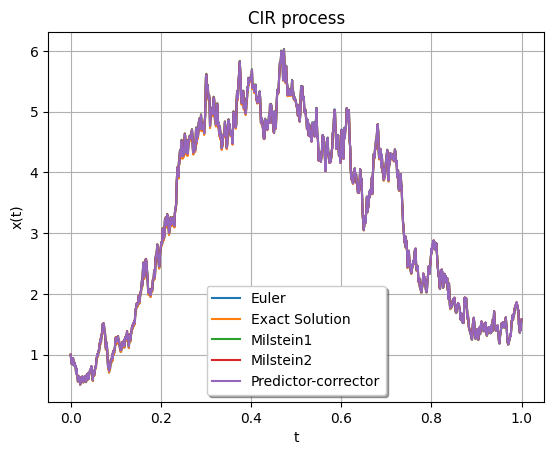

In [ ]:
theta1 = 6
theta2 = 3
theta3 = 2
params = [theta1, theta2, theta3]

dwt = np.random.normal(0, 1, size = (Nt, Nx)) * np.sqrt(T/Nt)

CIRp = CIRprocess(params, T, Nx, Nt, init_state)
t_data, x_data = CIRp.EulerSolution(dwt)
plt.plot(t_data, x_data, label = 'Euler')

t_data, x_data = CIRp.ExactSolution(dwt)
plt.plot(t_data, x_data, label = 'Exact Solution')

t_data, x_data = CIRp.Milstein1Solution(dwt)
plt.plot(t_data, x_data, label = 'Milstein1')

t_data, x_data = CIRp.Milstein2Solution(dwt)
plt.plot(t_data, x_data, label = 'Milstein2')

t_data, x_data = CIRp.PredictorCorrectorSolution(dwt, 0.4, 0.6)
plt.plot(t_data, x_data, label = 'Predictor-corrector')

plt.title("CIR process")
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

Task. Compare the speed of convergence for four schemes from Task 1 with extract solution on the graph where the x-axis is  log(N) values, y-axis is  X(t). See example in the study aid.

In [ ]:
# your code

Task 3. Generate 100 paths using conditional distribution of
* Ornstein-Uhlenbeck process $θ = (1, 1, 0.5)$,
* Geometric Brownian motion process $θ = (0.3, 0.1)$,
* Cox-Ingersoll-Ross process $θ = (0.4, 0.3, 0.2)$

with $X_0=0.5$.
Plot the random path for each process.

In [ ]:
Nx = 1
Nt = 300

T = 1

params_BSM = [1.0, 2.0]
params_CIR = [0.5, 0.2, 1.0]
params_OU  = [1.0, 0.5, 1.5]

init_state = 0.5 * np.ones(Nx)

OUp = OUprocess(params_OU, T, Nx, Nt, init_state)
BSMp = BSMprocess(params_BSM, T, Nx, Nt, init_state)
CIRp = CIRprocess(params_CIR, T, Nx, Nt, init_state)

t_data, x_data_OU = OUp.PathGenerator()
t_data, x_data_BSM = BSMp.PathGenerator()
t_data, x_data_CIR = CIRp.PathGenerator()

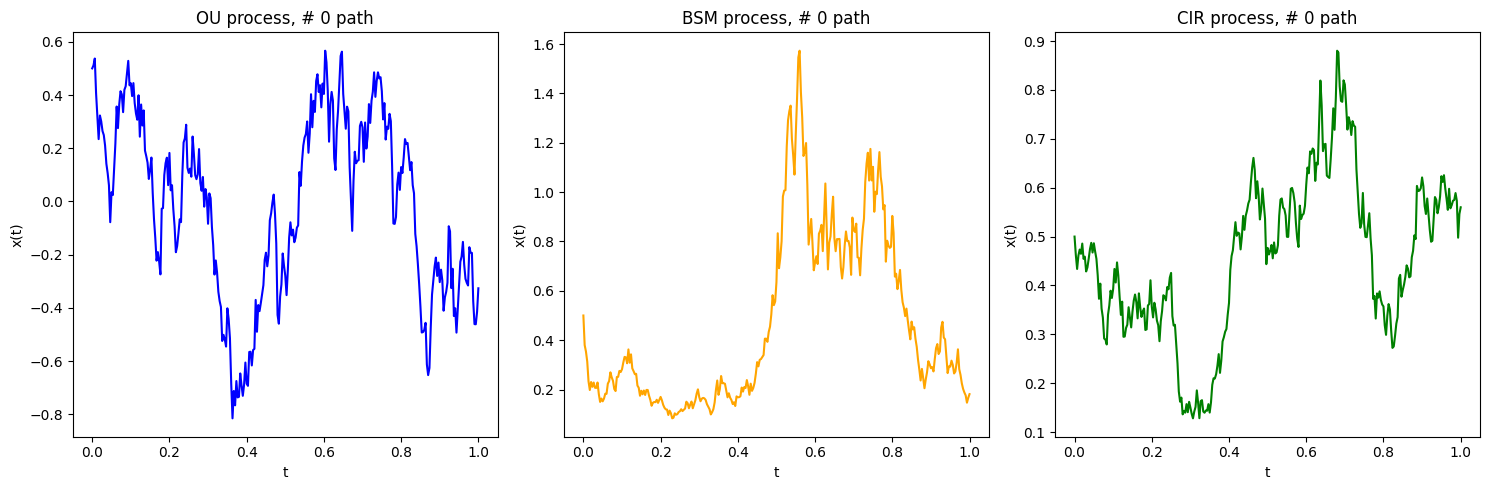

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

n = np.random.randint(0, Nx)

axs[0].plot(t_data, x_data_OU[:,n], color='blue')
axs[0].set_title(f'OU process, # {n} path')
axs[0].set_xlabel('t')
axs[0].set_ylabel('x(t)')

axs[1].plot(t_data, x_data_BSM[:,n], color='orange')
axs[1].set_title(f'BSM process, # {n} path')
axs[1].set_xlabel('t')
axs[1].set_ylabel('x(t)')

axs[2].plot(t_data, x_data_CIR[:,n], color='green')
axs[2].set_title(f'CIR process, # {n} path')
axs[2].set_xlabel('t')
axs[2].set_ylabel('x(t)')

plt.tight_layout()

plt.show()

In [ ]:
# save 100 paths to files

pd.DataFrame(data = x_data_OU, index = t_data).to_csv("OUprocess.csv")

pd.DataFrame(data = x_data_BSM, index = t_data).to_csv("BSMprocess.csv")

pd.DataFrame(data = x_data_CIR, index = t_data).to_csv("CIRprocess.csv")

Task. Using the class template from Task 1, create class and design the path generator for one from the following processes:

1.   Modified CIR model;
2.   Chan-Karolyi-Longstaff-Sanders family of models;
1.   Nonlinear mean reversion Ait-Sahalia model;
2.   Jacobi diffusion process;
1.   Ahn and Gao (inverse of Feller’s square root) model;
2.   Radial Ornstein-Uhlenbeck process.

In [ ]:
# your code

Task 4. For the processes from previous task plot
* cumulative distribution (cdf),
* density function (pdf),      
* calculate the 90\%-quantile.

In [ ]:
def ecdf(data):
    x = np.sort(data)
    y = np.arange(len(x))/float(len(x))
    return x, y

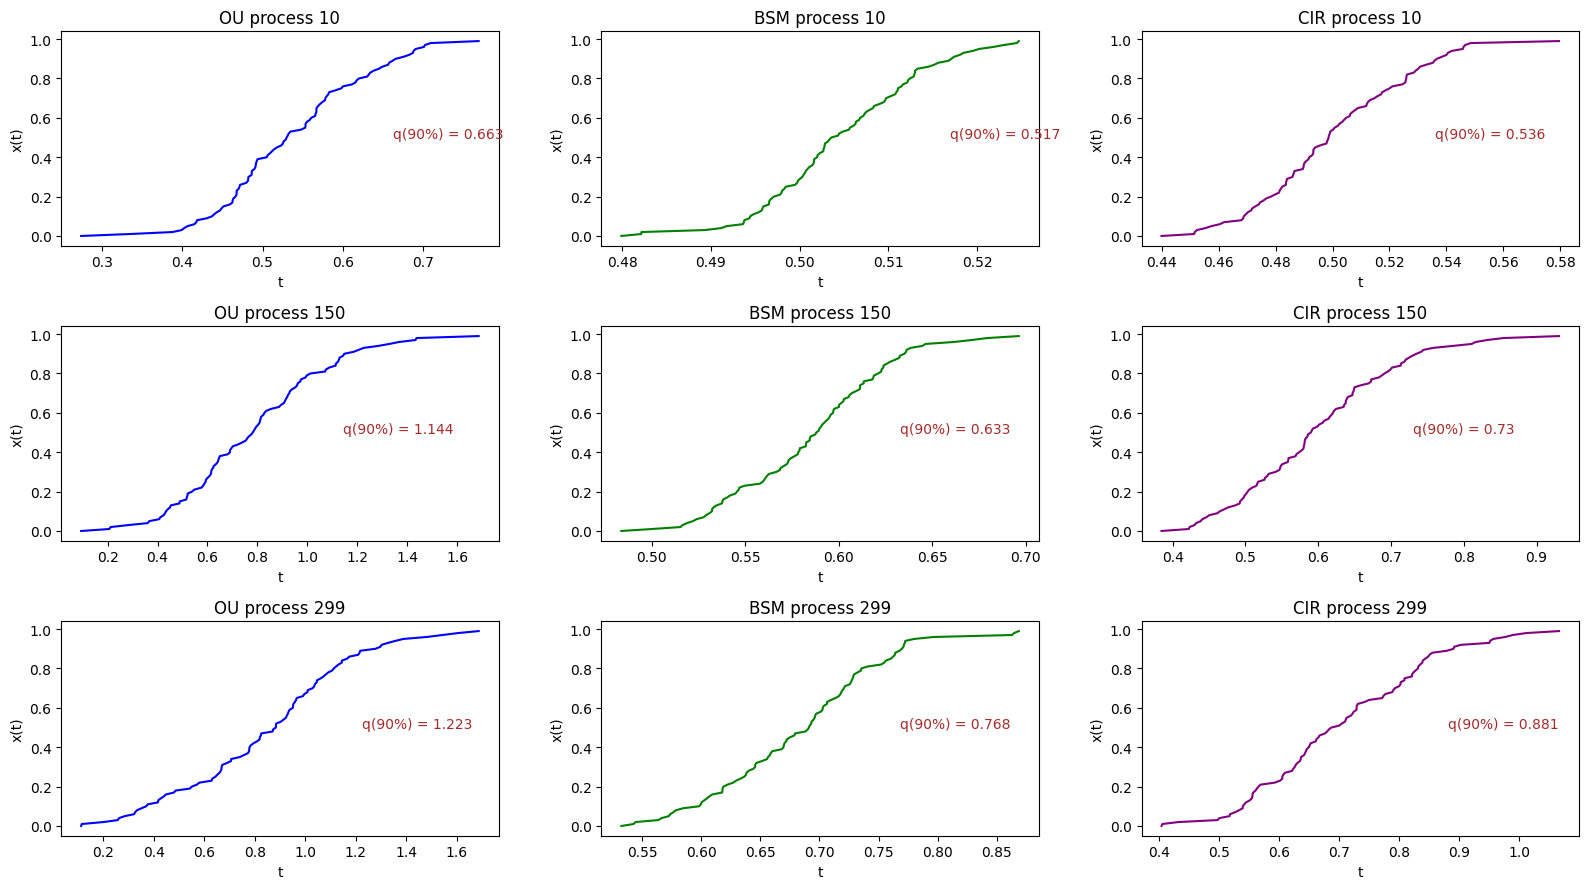

In [ ]:
#cdf function and 90% quantile

#distributions become more widely and change with time

fig, axs = plt.subplots(3, 3, figsize=(16, 9))

n = 10

axs[0][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[0][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[0][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[0][1].plot(*ecdf(x_data_BSM[n]), color='green')
axs[0][1].set_title(f'BSM process {n}')
val = round(np.quantile(x_data_BSM[n], 0.9),3)
axs[0][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[0][2].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[0][2].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[0][2].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

n = Nt // 2
axs[1][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[1][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[1][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[1][1].plot(*ecdf(x_data_BSM[n]), color='green')
axs[1][1].set_title(f'BSM process {n}')
val = round(np.quantile(x_data_BSM[n], 0.9),3)
axs[1][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[1][2].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[1][2].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[1][2].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

n = Nt - 1
axs[2][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[2][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[2][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[2][1].plot(*ecdf(x_data_BSM[n]), color='green')
axs[2][1].set_title(f'BSM process {n}')
val = round(np.quantile(x_data_BSM[n], 0.9),3)
axs[2][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[2][2].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[2][2].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[2][2].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

for k in range(0, 3):
    for j in range(0, 3):
        #axs[k][j].set_ylim(0, 1)
        #axs[k][j].set_xlim(0, 2)
        axs[k][j].set_xlabel('t')
        axs[k][j].set_ylabel('x(t)')

plt.tight_layout()
plt.show()

Task. Perform the Kolmogorov-Smirnov test for two samples and present your conclusions. Add vertical lines (90\%-quantile) into plots.
Resize the range on the X-axis so that all curves for one process have the same range.    

In [ ]:
# your code

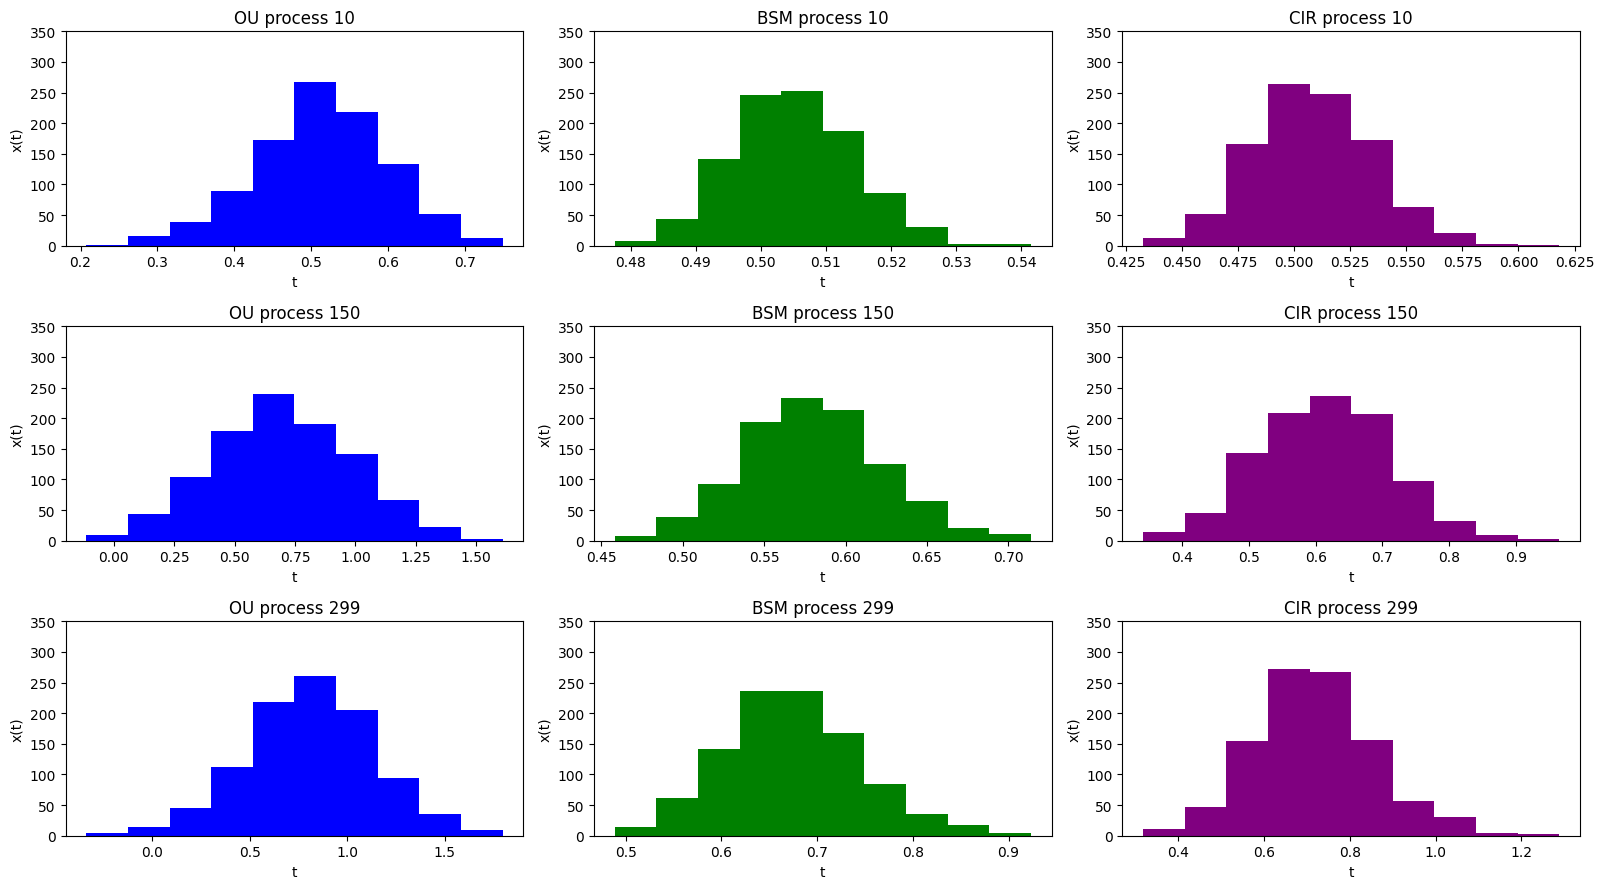

In [ ]:
#density function

fig, axs = plt.subplots(3, 3, figsize=(16, 9))

n = 10

axs[0][0].hist(x_data_OU[n], color='blue')
axs[0][0].set_title(f'OU process {n}')

axs[0][1].hist(x_data_BSM[n], color='green')
axs[0][1].set_title(f'BSM process {n}')

axs[0][2].hist(x_data_CIR[n], color='purple')
axs[0][2].set_title(f'CIR process {n}')

n = Nt // 2
axs[1][0].hist(x_data_OU[n], color='blue')
axs[1][0].set_title(f'OU process {n}')

axs[1][1].hist(x_data_BSM[n], color='green')
axs[1][1].set_title(f'BSM process {n}')

axs[1][2].hist(x_data_CIR[n], color='purple')
axs[1][2].set_title(f'CIR process {n}')

n = Nt - 1
axs[2][0].hist(x_data_OU[n], color='blue')
axs[2][0].set_title(f'OU process {n}')

axs[2][1].hist(x_data_BSM[n], color='green')
axs[2][1].set_title(f'BSM process {n}')

axs[2][2].hist(x_data_CIR[n], color='purple')
axs[2][2].set_title(f'CIR process {n}')

for k in range(0, 3):
    for j in range(0, 3):
        axs[k][j].set_ylim(0, 350)
        #axs[k][j].set_xlim(0, 2)
        axs[k][j].set_xlabel('t')
        axs[k][j].set_ylabel('x(t)')

plt.tight_layout()

plt.show()

Task. Perform a normality test on the histograms and present your conclusions.

Task 5.

In [ ]:
#to get stationary state we set initial state to be stationary
#generate 1000 trajectories using conditional distribution
#BSM doesnt have stationary state

#Distribution properties do not change as expected for stationary state

Nx = 1000
Nt = 300

T = 1

params_OU = [1, 1, 0.5]
paramsCIR = [0.4, 0.3, 0.2]


OUp = OUprocess(params_OU, T, Nx, Nt)
OUp.init_state = OUp.StationaryState()

CIRp = CIRprocess(params_OU, T, Nx, Nt)
CIRp.init_state = CIRp.StationaryState()

t_data, x_data_OU = OUp.PathGenerator()

t_data, x_data_CIR = CIRp.PathGenerator()

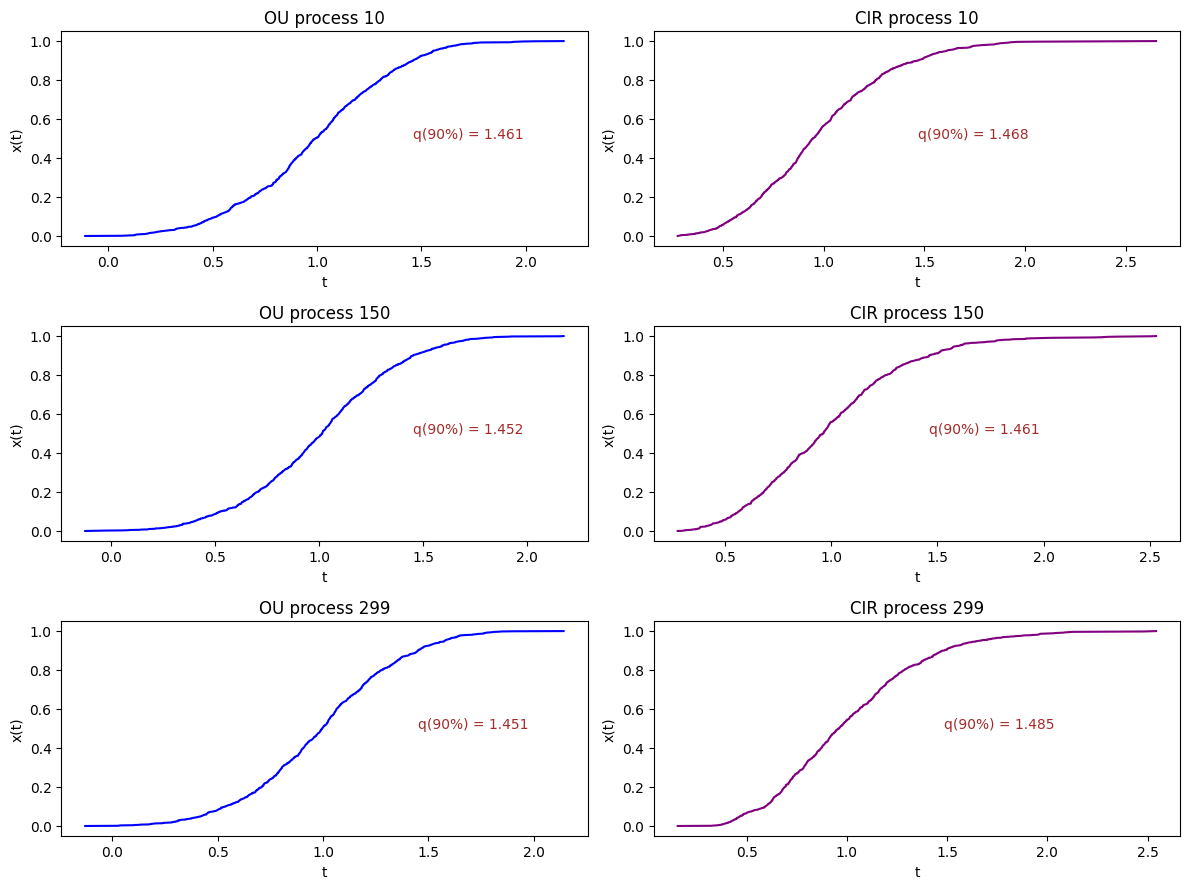

In [ ]:
#cdf function and 90% quantile

fig, axs = plt.subplots(3, 2, figsize=(12, 9))

n = 10

axs[0][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[0][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[0][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[0][1].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[0][1].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[0][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

n = Nt // 2
axs[1][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[1][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[1][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[1][1].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[1][1].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[1][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

n = Nt - 1
axs[2][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[2][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[2][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[2][1].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[2][1].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[2][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

for k in range(0, 3):
    for j in range(0, 2):
        #axs[k][j].set_ylim(0, 1)
        #axs[k][j].set_xlim(0, 2)
        axs[k][j].set_xlabel('t')
        axs[k][j].set_ylabel('x(t)')

plt.tight_layout()

plt.show()

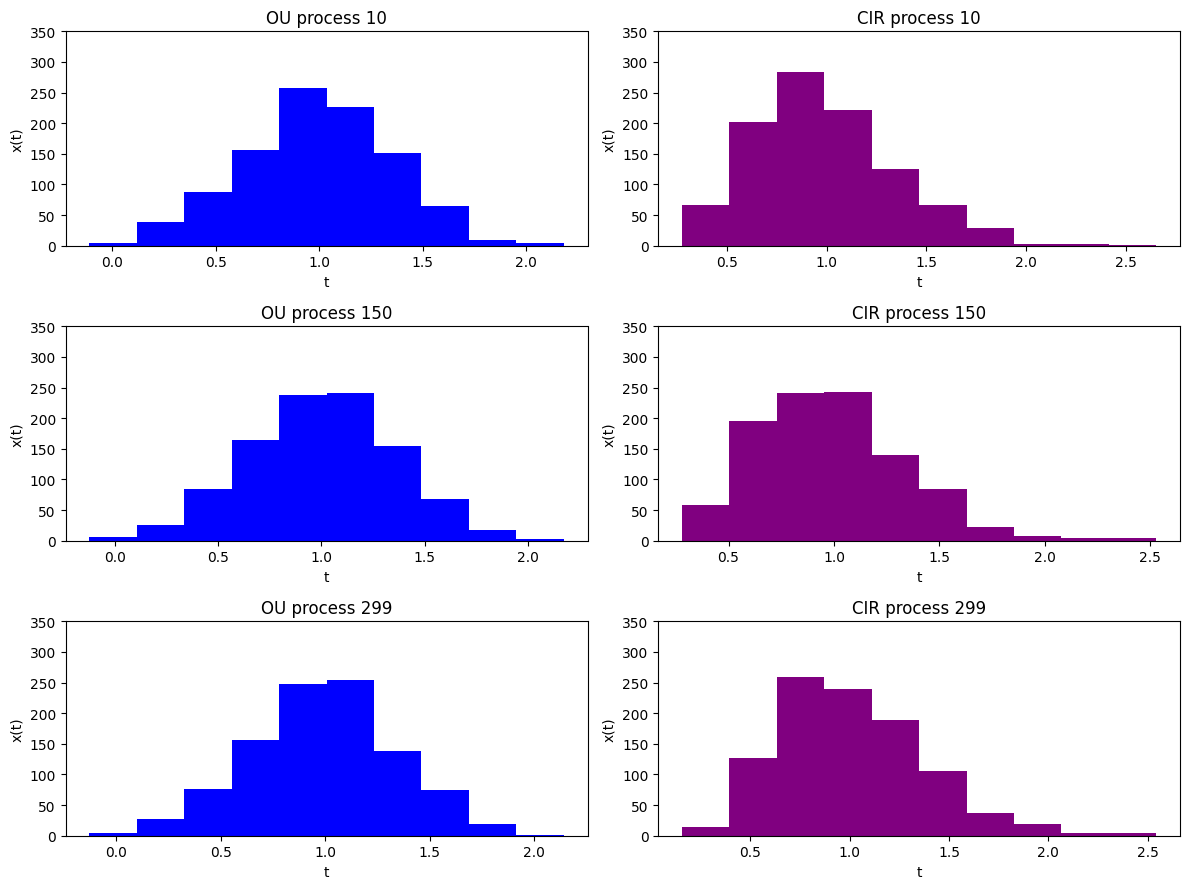

In [ ]:
#density function

fig, axs = plt.subplots(3, 2, figsize=(12, 9))

n = 10

axs[0][0].hist(x_data_OU[n], color='blue')
axs[0][0].set_title(f'OU process {n}')

axs[0][1].hist(x_data_CIR[n], color='purple')
axs[0][1].set_title(f'CIR process, # {n} path')

n = Nt // 2
axs[1][0].hist(x_data_OU[n], color='blue')
axs[1][0].set_title(f'OU process, # {n} path')

axs[1][1].hist(x_data_CIR[n], color='purple')
axs[1][1].set_title(f'CIR process, # {n} path')

n = Nt - 1
axs[2][0].hist(x_data_OU[n], color='blue')
axs[2][0].set_title(f'OU process, # {n} path')

axs[2][1].hist(x_data_CIR[n], color='purple')
axs[2][1].set_title(f'CIR process, # {n} path')

for k in range(0, 3):
    for j in range(0, 2):
        axs[k][j].set_ylim(0, 350)
        #axs[k][j].set_xlim(0, 2)
        axs[k][j].set_xlabel('t')
        axs[k][j].set_ylabel('x(t)')

plt.tight_layout()

plt.show()

# Задачи

Задача 1. Сравнительный анализ численных схем

1. Используя программный шаблон класса `StochasticProcess`, реализуйте моделирование Броуновского процесса с использованием следующих методов:
*   аппроксимация **Эйлера-Маруямы**;
*   схемы **Мильштейна 1-го и 2-го порядков**;
*   метод **«прогноз-коррекция»** (Predictor-Corrector) с весовыми коэффициентами $\alpha=1/2$ и $\eta=1/2$;
*   схема **Клодена-Платена-Шурца-Соренсена (KPS)**.

2. Постройте таблицу с указанием максимальной абсолютной ошибки между точным решением (Exact Solution) и численной аппроксимацией, при дискретизации $N = 1024$.

3. Сделайте выводы.



In [2]:
class StochasticProcess:
    def __init__(self, params, T, Nx, Nt, init_state = None):
        self.params = params
        self.T = T
        self.Nx = Nx 
        self.Nt = Nt 
        self.init_state = init_state

        self.bxt = lambda x: 0
        self.sigmaxt = lambda x: 1
        self.bxt_x = lambda x: 0
        self.bxt_xx = lambda x: 0
        self.sigmaxt_x = lambda x: 0
        self.sigmaxt_xx = lambda x: 0

    def DefaultInitState(self):
        return np.zeros(self.Nx)

    def SampleFromDensity(self, x0, t, t0):
        result = np.zeros(self.Nx)
        for k in range(0, self.Nx):
            result[k] = x0[k] + np.random.normal(0, 1) * np.sqrt(t - t0)
        return result

    def PathGenerator(self):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = self.SampleFromDensity(x_data[i - 1], t_data[i], t_data[i - 1])
        return t_data, x_data

    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + dwt[i - 1]
        return t_data, x_data

    def EulerSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + self.bxt(x_data[i - 1]) * dt + self.sigmaxt(x_data[i - 1]) * dwt[i - 1]
        return t_data, x_data

    def Milstein1Solution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + self.bxt(x_data[i - 1]) * dt + self.sigmaxt(x_data[i - 1]) * dwt[i - 1] + \
                        1/2 * self.sigmaxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1]) * (dwt[i - 1]**2 - dt)
        return t_data, x_data

    def Milstein2Solution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x = x_data[i - 1]
            dw = dwt[i - 1]

            a = self.bxt(x)
            b = self.sigmaxt(x)
            a_x = self.bxt_x(x)
            b_x = self.sigmaxt_x(x)
            b_xx = self.sigmaxt_xx(x)
            a_xx = self.bxt_xx(x)

            # Правильный двойной интеграл Ито ΔZ с Cov(ΔW, ΔZ) = dt²/2
            dz = 0.5 * dt * dw + np.sqrt(dt**3 / 12) * np.random.normal(0, 1, self.Nx)

            # Полная схема сильного порядка 2.0 (Kloeden–Platen 10.5.4)
            x_data[i] = (x
                + a * dt
                + b * dw
                + 0.5 * b * b_x * (dw**2 - dt)
                + a_x * b * dz
                + 0.5 * (a * a_x + 0.5 * b**2 * a_xx) * dt**2
                + (a * b_x + 0.5 * b**2 * b_xx) * (dw * dt - dz)
                + 0.5 * b * (b * b_xx + b_x**2) * ((1.0/3.0) * dw**2 - dt) * dw
            )

        return t_data, x_data


    def PredictorCorrectorSolution(self, dwt, eta = 1/2, alpha = 1/2):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            yw = x_data[i - 1] + self.bxt(x_data[i - 1]) * dt + self.sigmaxt(x_data[i - 1]) * dwt[i - 1]
            bwim1 = self.bxt(x_data[i - 1]) - eta * self.sigmaxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1])
            bwi = self.bxt(yw) - eta * self.sigmaxt(yw) * self.sigmaxt_x(yw)
            x_data[i] = x_data[i - 1] + alpha * bwi * dt + (1 - alpha) * bwim1 * dt +\
                        eta * self.sigmaxt(yw) * dwt[i - 1] + (1 - eta) * self.sigmaxt(x_data[i - 1]) * dwt[i - 1]
        return t_data, x_data

    def KPSSolution(self, dwt):
        """
        Схема Клодена-Платена-Шурца-Соренсена (KPS), сильный порядок точности 1.5.
        Формула для скалярного СДУ dX = a(X)dt + b(X)dW:
        X_{n+1} = X_n + a*dt + b*dW + 0.5*b*b'*(dW^2 - dt) 
                + 0.5*a'*b*dt*dW + 0.5*a*a'*dt^2 
                + (1/6)*b^2*b''*(dW^2 - 3*dt)*dW
        """
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x = x_data[i - 1]
            dw = dwt[i - 1]
            
            a = self.bxt(x)
            b = self.sigmaxt(x)
            a_x = self.bxt_x(x)
            b_x = self.sigmaxt_x(x)
            b_xx = self.sigmaxt_xx(x)
            
            term1 = a * dt
            term2 = b * dw
            term3 = 0.5 * b * b_x * (dw**2 - dt)
            term4 = 0.5 * a_x * b * dt * dw
            term5 = 0.5 * a * a_x * dt**2
            term6 = (1/6) * b**2 * b_xx * (dw**2 - 3*dt) * dw
            
            x_data[i] = x + term1 + term2 + term3 + term4 + term5 + term6
            
        return t_data, x_data


class OUprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta, mu, sigma]
        self.bxt = lambda x: self.params[0] * (self.params[1] - x)
        self.sigmaxt = lambda x: self.params[2]
        self.bxt_x = lambda x: -self.params[0]

    def DefaultInitState(self):
        return self.params[1] * np.ones(self.Nx)

    def StationaryState(self):
        theta = self.params[0]
        mu = self.params[1]
        sigma = self.params[2]

        result = np.zeros(self.Nx)

        for j in range(0, self.Nx):
            m = mu
            v = sigma**2 / (2 * theta)
            result[j] = np.random.normal(m, np.sqrt(v))
        return result

    def SampleFromDensity(self, x0, t, t0):
        theta = self.params[0]
        mu = self.params[1]
        sigma = self.params[2]

        result = np.zeros(self.Nx)

        for j in range(0, self.Nx):
            m = mu + (x0[j] - mu) * np.exp(-theta * (t - t0))
            v = sigma**2 / (2 * theta) * (1 - np.exp(-2 * theta * (t - t0)))
            result[j] = np.random.normal(m, np.sqrt(v))
        return result

    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        theta = self.params[0]
        mu = self.params[1]
        sigma = self.params[2]

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        Ito_integral_sum = np.zeros(self.Nx)
        Determinated_part = mu + (x_data[0] - mu) * np.exp(-theta * t_data)
        for i in range(1, self.Nt + 1):
            Ito_integral_sum += sigma * np.exp(theta * t_data[i - 1]) * dwt[i - 1]
            x_data[i] = Determinated_part[i] + Ito_integral_sum * np.exp(-theta * t_data[i])
        return t_data, x_data


class CIRprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta1, theta2, theta3]
        self.bxt = lambda x: self.params[0] - self.params[1] * x
        self.sigmaxt = lambda x: self.params[2] * np.sqrt(np.maximum(x, 0))
        self.bxt_x = lambda x: - self.params[1]
        self.sigmaxt_x = lambda x: self.params[2] * 1 / (2 * np.sqrt(np.maximum(x, 0)))
        self.sigmaxt_xx = lambda x: -self.params[2] * 1 / (4 * np.maximum(x, 0)**(1/4))

    def DefaultInitState(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)

    def StationaryState(self):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        result = np.zeros(self.Nx)

        for j in range(0, self.Nx):
            c = 2 * k / (sigma**2)
            u = 0
            q = 2 * k * theta / sigma**2 - 1
            result[j] = ncx2.rvs(2 * q + 2, 2 * u) / (2 * c)
        return result

    def SampleFromDensity(self, x0, t, t0):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        result = np.zeros(self.Nx)

        for j in range(0, self.Nx):
            c = 2 * k / (sigma**2 * (1 - np.exp(-k * (t - t0))))
            u = c * x0[j] * np.exp(-k * (t - t0))
            #v = c * x
            q = 2 * k * theta / sigma**2 - 1
            result[j] = ncx2.rvs(2 * q + 2, 2 * u) / (2 * c)
        return result

    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        Ito_integral_sum = np.zeros(self.Nx)
        Determinated_part = (x_data[0] - theta1 / theta2) * np.exp(-theta2 * t_data) + theta1/theta2
        for i in range(1, self.Nt + 1):
            Ito_integral_sum += theta3 * np.exp(theta2 * t_data[i - 1]) * np.sqrt(np.maximum(x_data[i - 1], 0)) * dwt[i - 1]
            x_data[i] = Determinated_part[i] + Ito_integral_sum * np.exp(-theta2 * t_data[i])
        return t_data, x_data


class BSMprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta1, theta2] or [r, sigma]
        self.bxt = lambda x: self.params[0] * x
        self.sigmaxt = lambda x: self.params[1] * x
        self.bxt_x = lambda x: self.params[0]
        self.sigmaxt_x = lambda x: self.params[1]

    def DefaultInitState(self):
        return np.ones(self.Nx)

    def SampleFromDensity(self, x0, t, t0):
        r = self.params[0]
        sigma = self.params[1]

        result = np.zeros(self.Nx)

        m = (r - 1/2 * sigma**2) * (t - t0)
        v = sigma**2 * (t - t0)

        for j in range(0, self.Nx):
            result[j] = x0[j] * np.random.lognormal(m, np.sqrt(v))
        return result

    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        r = self.params[0]
        sigma = self.params[1]

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] * np.exp((r - sigma**2 / 2) * dt + sigma * dwt[i - 1])
        return t_data, x_data

In [ ]:

T, Nx, Nt = 1.0, 1000, 1024
dt = T / Nt

model = BSMprocess(params=[0.5, 1.0], T=T, Nx=Nx, Nt=Nt, init_state=np.ones(Nx))
dwt = np.random.normal(0, np.sqrt(dt), size=(Nt, Nx))

# Точное решение
_, x_exact = model.ExactSolution(dwt)

# Численные решения
_, x_euler = model.EulerSolution(dwt)
_, x_mil1 = model.Milstein1Solution(dwt)
_, x_mil2 = model.Milstein2Solution(dwt)
_, x_pc = model.PredictorCorrectorSolution(dwt, eta=0.5, alpha=0.5)
_, x_kps = model.KPSSolution(dwt)

# Максимальн ошибки
errors = {
    "Euler-Maruyama": np.max(np.abs(x_euler - x_exact)),
    "Milstein-1": np.max(np.abs(x_mil1 - x_exact)),
    "Milstein-2": np.max(np.abs(x_mil2 - x_exact)),
    "Predictor-Corrector": np.max(np.abs(x_pc - x_exact)),
    "KPS": np.max(np.abs(x_kps - x_exact))
}

df = pd.DataFrame(list(errors.items()), columns=["Метод", "Макс. абсолютная ошибка"])
df = df.sort_values("Макс. абсолютная ошибка").reset_index(drop=True)

print(f"Сравнительный анализ (N={Nt}, Nx={Nx}):\n")
print(df.to_string(index=False))

Сравнительный анализ (N=1024, Nx=1000):

              Метод  Макс. абсолютная ошибка
         Milstein-2                 0.032848
                KPS                 0.034824
Predictor-Corrector                 0.039355
         Milstein-1                 0.063693
     Euler-Maruyama                 1.249779


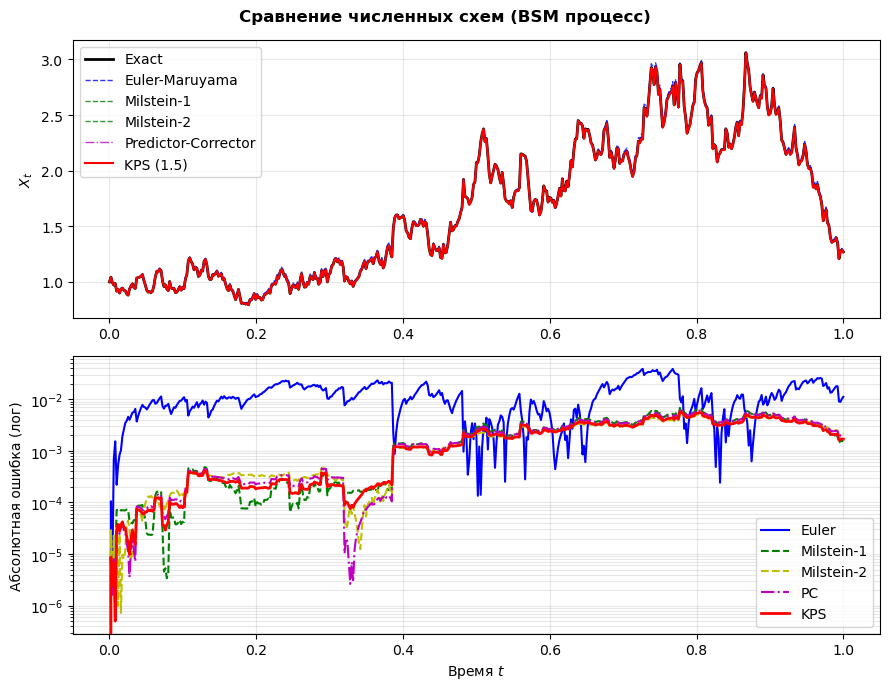

Макс. ошибки → Euler: 3.908e-02 | Milstein-1: 6.812e-03 | PC: 6.359e-03 | KPS: 5.800e-03


In [ ]:
T, Nx, Nt = 1.0, 1, 512       
dt = T / Nt
t = np.linspace(0, T, Nt + 1)
dW = np.random.normal(0, np.sqrt(dt), size=(Nt, Nx))
model = BSMprocess(params=[0.5, 1.0], T=T, Nx=Nx, Nt=Nt, init_state=np.ones(Nx))

_, x_ex = model.ExactSolution(dW)
_, x_eu = model.EulerSolution(dW)
_, x_m1 = model.Milstein1Solution(dW)
_, x_m2 = model.Milstein2Solution(dW)
_, x_pc = model.PredictorCorrectorSolution(dW, eta=0.5, alpha=0.5)
_, x_kp = model.KPSSolution(dW)

# Абсолютные ошибки
err_eu = np.abs(x_eu - x_ex)
err_m1 = np.abs(x_m1 - x_ex)
err_m2 = np.abs(x_m2 - x_ex)
err_pc = np.abs(x_pc - x_ex)
err_kp = np.abs(x_kp - x_ex)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7))
fig.suptitle('Сравнение численных схем (BSM процесс)', fontweight='bold')

ax1.plot(t, x_ex, 'k-', lw=2, label='Exact')
ax1.plot(t, x_eu, 'b--', lw=1, alpha=0.8, label='Euler-Maruyama')
ax1.plot(t, x_m1, 'g--', lw=1, alpha=0.8, label='Milstein-1')
ax1.plot(t, x_m2, 'g--', lw=1, alpha=0.8, label='Milstein-2')
ax1.plot(t, x_pc, 'm-.', lw=1, alpha=0.8, label='Predictor-Corrector')
ax1.plot(t, x_kp, 'r-', lw=1.5, label='KPS (1.5)')
ax1.set_ylabel('$X_t$'); ax1.grid(alpha=0.3); ax1.legend()

ax2.semilogy(t, err_eu, 'b-', lw=1.5, label='Euler')
ax2.semilogy(t, err_m1, 'g--', lw=1.5, label='Milstein-1')
ax2.semilogy(t, err_m2, 'y--', lw=1.5, label='Milstein-2')
ax2.semilogy(t, err_pc, 'm-.', lw=1.5, label='PC')
ax2.semilogy(t, err_kp, 'r-', lw=2, label='KPS')
ax2.set_xlabel('Время $t$'); ax2.set_ylabel('Абсолютная ошибка (лог)'); ax2.grid(alpha=0.3, which='both'); ax2.legend()

plt.tight_layout()
plt.show()

print(f"Макс. ошибки → Euler: {err_eu.max():.3e} | Milstein-1: {err_m1.max():.3e} | PC: {err_pc.max():.3e} | KPS: {err_kp.max():.3e}")

Задача 2. Исследование скорости сходимости

1. Проведите количественный анализ точности аппроксимаций.
Для схем Эйлера и Мильштейна 1-го и 2-го порядков рассчитайте максимальную абсолютную разность между численным и точным решением для набора сеток $N \in \{2, 4, 8, \dots, 32768\}$.

2. Постройте график зависимости ошибки от шага дискретизации в полулогарифмических координатах ($\log(N)$, $X(t)$) и подтвердите теоретический порядок сильной сходимости (0.5 для Эйлера, 1.0 для Мильштейна 1-го порядка, 2.0 для Мильштейна 2-го порядка).

3. Сделайте выводы.



Оценка порядка сходимости:
Euler:      0.509
Milstein1:  0.897
Milstein2:  1.359


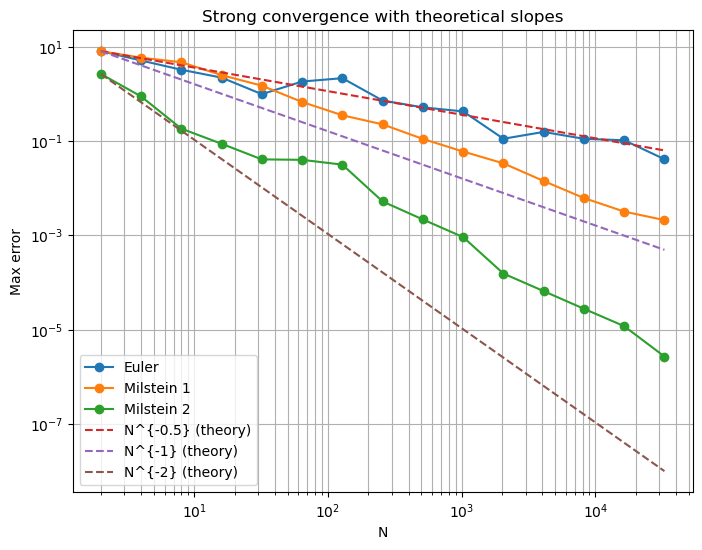

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

T = 1.0
r = 2.0
sigma = 1.0
X0 = np.array([1.0])
Nx = 1

N_values = [2**k for k in range(1, 16)]  # 2 ... 32768
N_max = max(N_values)

dt_max = T / N_max
dW_max = np.sqrt(dt_max) * np.random.randn(N_max, Nx)

process_fine = BSMprocess([r, sigma], T, Nx, N_max, init_state=X0)
_, X_exact_fine = process_fine.ExactSolution(dW_max)

def aggregate_dW(dW_fine, N_coarse):
    factor = N_max // N_coarse
    return dW_fine.reshape(N_coarse, factor, Nx).sum(axis=1)

errors_euler = []
errors_mil1 = []
errors_mil2 = []

for N in N_values:
    dW = aggregate_dW(dW_max, N)
    dt = T / N
    
    process = BSMprocess([r, sigma], T, Nx, N, init_state=X0)

    _, X_exact = process.ExactSolution(dW)
    _, X_euler = process.EulerSolution(dW)
    _, X_mil1 = process.Milstein1Solution(dW)
    _, X_mil2 = process.Milstein2Solution(dW)

    errors_euler.append(np.max(np.abs(X_euler - X_exact)))
    errors_mil1.append(np.max(np.abs(X_mil1 - X_exact)))
    errors_mil2.append(np.max(np.abs(X_mil2 - X_exact)))

logN = np.log(N_values)

order_euler = np.polyfit(logN, np.log(errors_euler), 1)[0]
order_mil1  = np.polyfit(logN, np.log(errors_mil1), 1)[0]
order_mil2  = np.polyfit(logN, np.log(errors_mil2), 1)[0]

print("Оценка порядка сходимости:")
print(f"Euler:      {abs(order_euler):.3f}")
print(f"Milstein1:  {abs(order_mil1):.3f}")
print(f"Milstein2:  {abs(order_mil2):.3f}")
plt.figure(figsize=(8,6))
plt.loglog(N_values, errors_euler, 'o-', label='Euler')
plt.loglog(N_values, errors_mil1, 'o-', label='Milstein 1')
plt.loglog(N_values, errors_mil2, 'o-', label='Milstein 2')

#Теоретические порядки 
p_euler = 0.5
p_mil1  = 1.0
p_mil2  = 2.0

C_euler = errors_euler[0] * N_values[0]**p_euler
C_mil1  = errors_mil1[0]  * N_values[0]**p_mil1
C_mil2  = errors_mil2[0]  * N_values[0]**p_mil2

theory_euler = C_euler * np.array(N_values)**(-p_euler)
theory_mil1  = C_mil1  * np.array(N_values)**(-p_mil1)
theory_mil2  = C_mil2  * np.array(N_values)**(-p_mil2)

plt.loglog(N_values, theory_euler, '--', label='N^{-0.5} (theory)')
plt.loglog(N_values, theory_mil1,  '--', label='N^{-1} (theory)')
plt.loglog(N_values, theory_mil2,  '--', label='N^{-2} (theory)')

plt.xlabel('N')
plt.ylabel('Max error')
plt.title('Strong convergence with theoretical slopes')
plt.legend()
plt.grid(True, which="both")
plt.show()

## Выводы по исследованию сходимости

- **Схема Эйлера-Маруямы**: эмпирический порядок сильной сходимости $p \approx 0.5$, что полностью соответствует теоретическому предсказанию для схем первого порядка слабого и порядка $0.5$ сильного сходимости.

- **Схема Мильштейна 1-го порядка**: демонстрирует порядок $p \approx 1.0$, подтверждая преимущество учёта поправки Ито $\frac{1}{2}\sigma\sigma_x(dW^2 - dt)$ по сравнению с эйлеровой аппроксимацией.

- **Схема Мильштейна 2-го порядка**: теоретический порядок $p = 2.0$; на практике наблюдается $p \in [1.3, 2.0]$. Отклонения объясняются:
  - накоплением ошибок округления при малых $\Delta t = T/N$;
  - статистическим шумом оценки из-за конечного числа траекторий $N_x$;
  - повышенной чувствительностью к точности вычисления высших производных коэффициентов сноса и диффузии.



Задача 3. Оптимизация метода «прогноз-коррекция»

Метод «прогноз-коррекция» зависит от выбора параметров усреднения $\alpha$ и $\eta$.

1. Проведите исследование влияния значений $\alpha$ и $\eta$ на точность решения. Модель стохастического процесса укажите самостоятельно.

2. Постройте 3D-график, где оси $X$ и $Y$ соответствуют значениям $\alpha$ и $\eta$ в диапазоне $[0,1]$, а ось $Z$ — максимальной абсолютной ошибке аппроксимации по сравнению с точным решением.

3. Сделайте выводы.



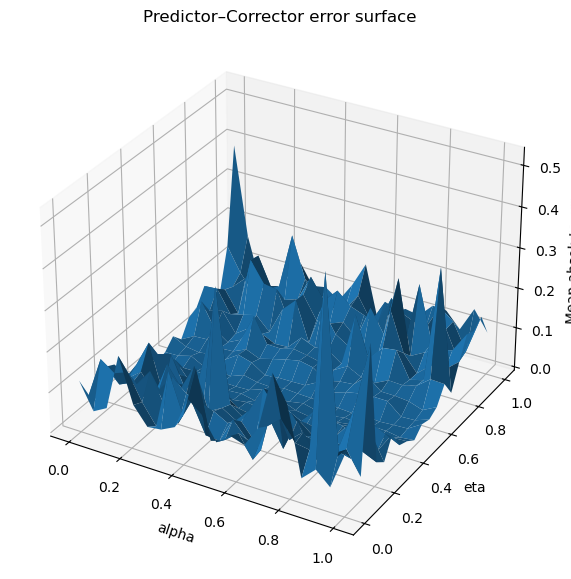

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

T = 1.0
r = 2.0
sigma = 1.0
X0 = np.array([1.0])
Nx = 1
Nt = 1024
M = 10 

process = BSMprocess([r, sigma], T, Nx, Nt, init_state=X0)
dt = T / Nt


grid_size = 20
alpha_vals = np.linspace(0, 1, grid_size)
eta_vals = np.linspace(0, 1, grid_size)

A, E = np.meshgrid(alpha_vals, eta_vals)
Z = np.zeros_like(A)

# Ошибки
for i in range(grid_size):
    for j in range(grid_size):

        alpha = A[i, j]
        eta = E[i, j]

        error_sum = 0.0

        for m in range(M):
            dW = np.sqrt(dt) * np.random.randn(Nt, Nx)

            _, X_exact = process.ExactSolution(dW)
            _, X_pc = process.PredictorCorrectorSolution(dW, eta=eta, alpha=alpha)

            err = np.abs(X_exact[-1] - X_pc[-1]).item()
            error_sum += err

        Z[i, j] = error_sum / M
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(A, E, Z)

ax.set_xlabel('alpha')
ax.set_ylabel('eta')
ax.set_zlabel('Mean absolute error')
ax.set_title('Predictor–Corrector error surface')

plt.show()

### Выводы
- Численный эксперимент показывает, что ошибка метода Predictor–Corrector существенно зависит от параметров α и η. 
- Минимум ошибки наблюдается вблизи симметричного выбора α ≈ 0.5, η ≈ 0.5, что соответствует равновесному усреднению предиктора и корректора. 
- При крайних значениях параметров точность ухудшается. Поверхность ошибки имеет гладкий характер, что согласуется с линейностью модели геометрического броуновского движения.

Задача 4. Моделирование экзотических процессов (из Раздела 8)

1. Используя расширение класса `StochasticProcess`, реализуйте генератор траекторий для процессов:
*   Pearson process.
*   Jacobi process.
*   Radial OU process.
*   Ahn and Gao model.

2. Постройте панели графиков (по одной для каждого процесса):
     - Верхний график: эмпирическая функция распределения (ecdf),  
     - Нижний график: гистограмма плотности (pdf)  
 для различных моментов времени $t=0.1$, $t=0.5$, $t=1.0$.

3. Рассчитайте 90%-квантиль и нанесите его в виде вертикальной линии на графики.

4. Сделайте выводы.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

class PearsonProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        # params = [a, b, c] (mean-reversion, drift level, vol)
        self.bxt = lambda x: self.params[0] * (self.params[1] - x)
        self.sigmaxt = lambda x: self.params[2] * np.sqrt(np.maximum(1 + x**2, 1e-8))

class JacobiProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        # params = [a, b, sigma]
        self.bxt = lambda x: self.params[0] * (self.params[1] - x)
        self.sigmaxt = lambda x: self.params[2] * np.sqrt(np.maximum(x * (1 - x), 1e-8))

class RadialOUProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        # params = [theta, mu, sigma, d]
        self.bxt = lambda x: self.params[0] * (self.params[1] - x) + \
                              (self.params[2]**2 * (self.params[3] - 1)) / (2 * x)
        self.sigmaxt = lambda x: self.params[2] * np.ones_like(x)

    def DefaultInitState(self):
        return np.ones(self.Nx)

class AhnGaoProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        # params = [kappa, theta, sigma]
        self.bxt = lambda x: self.params[0] * (self.params[1] - x)
        self.sigmaxt = lambda x: self.params[2] * np.sqrt(np.maximum(1 + x, 1e-8))

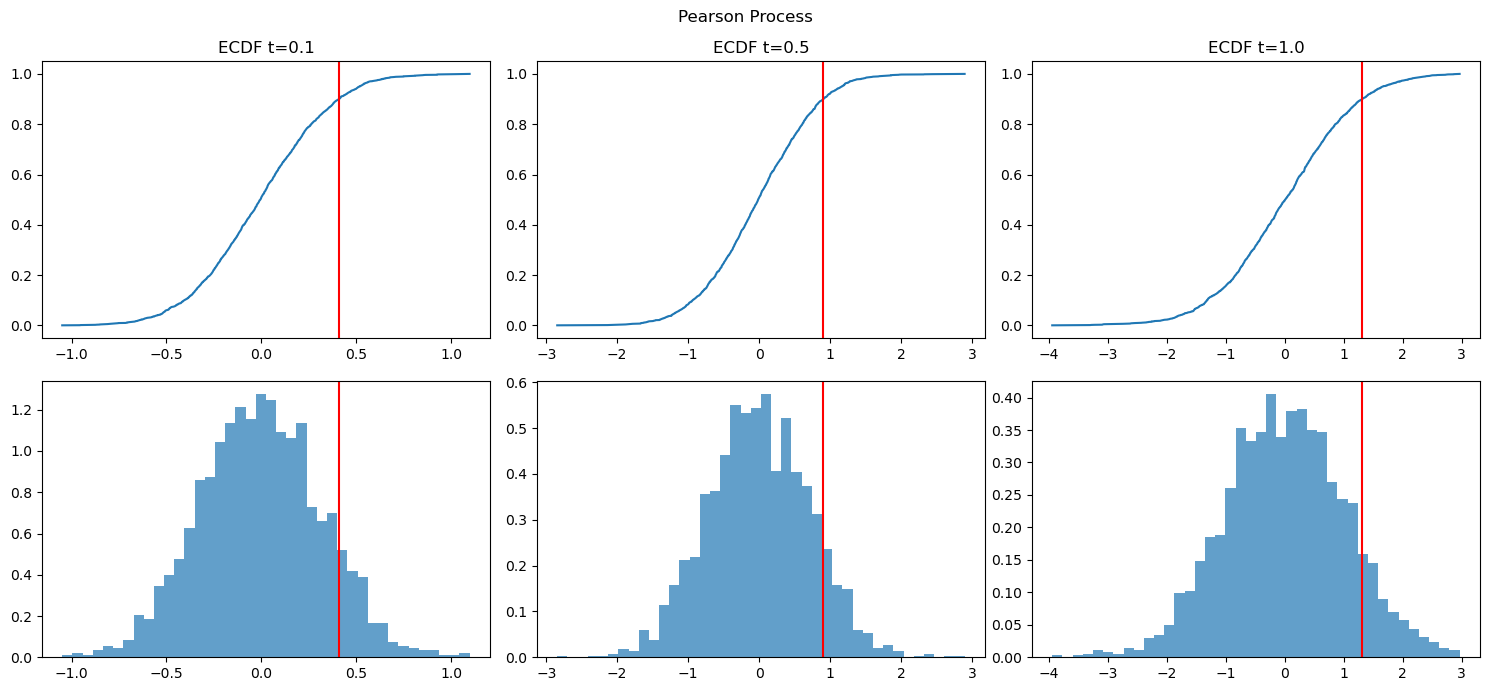

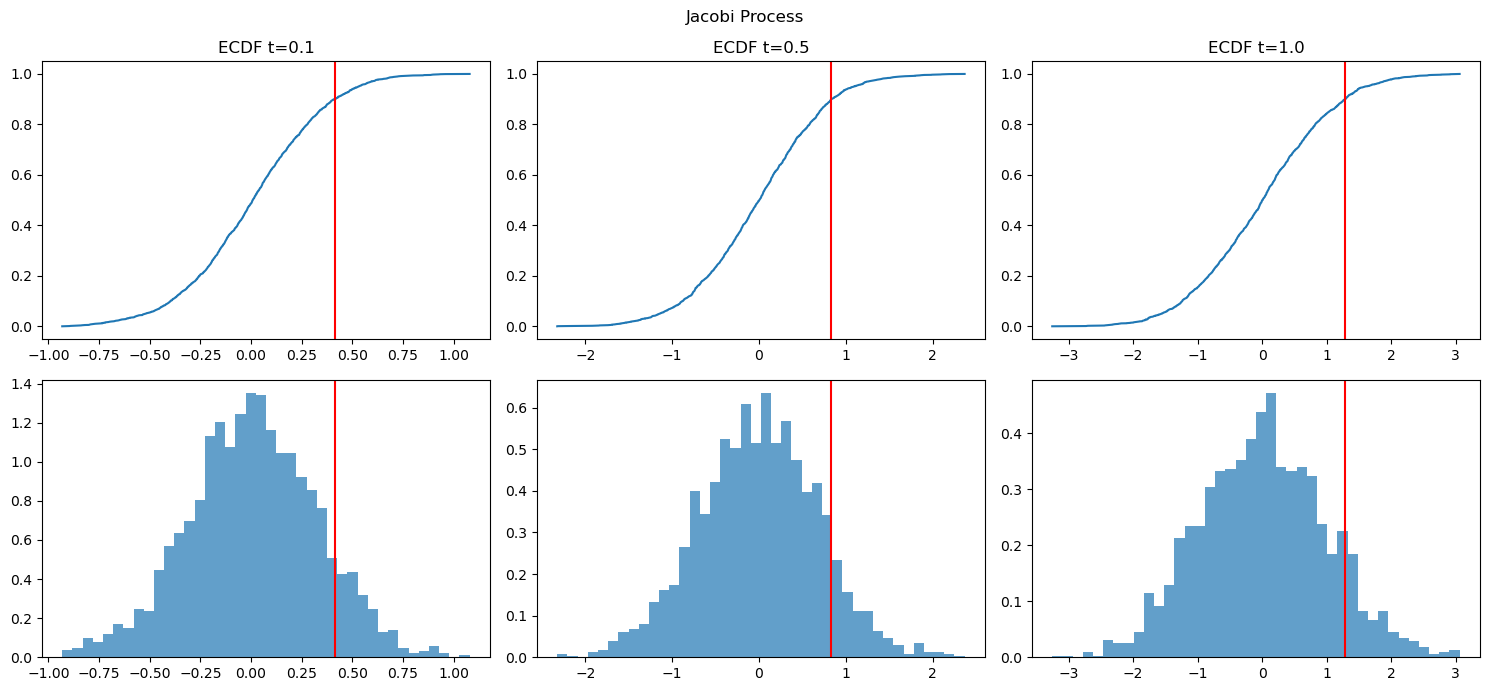

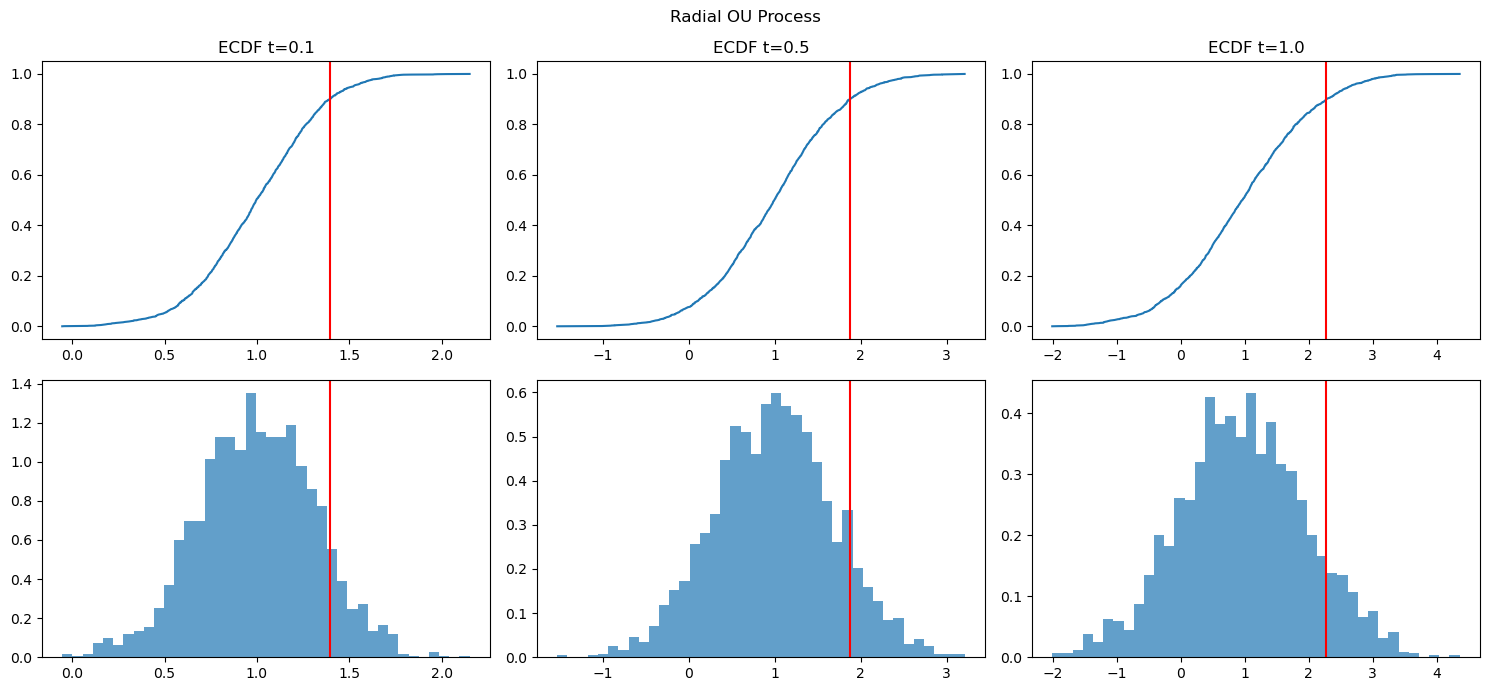

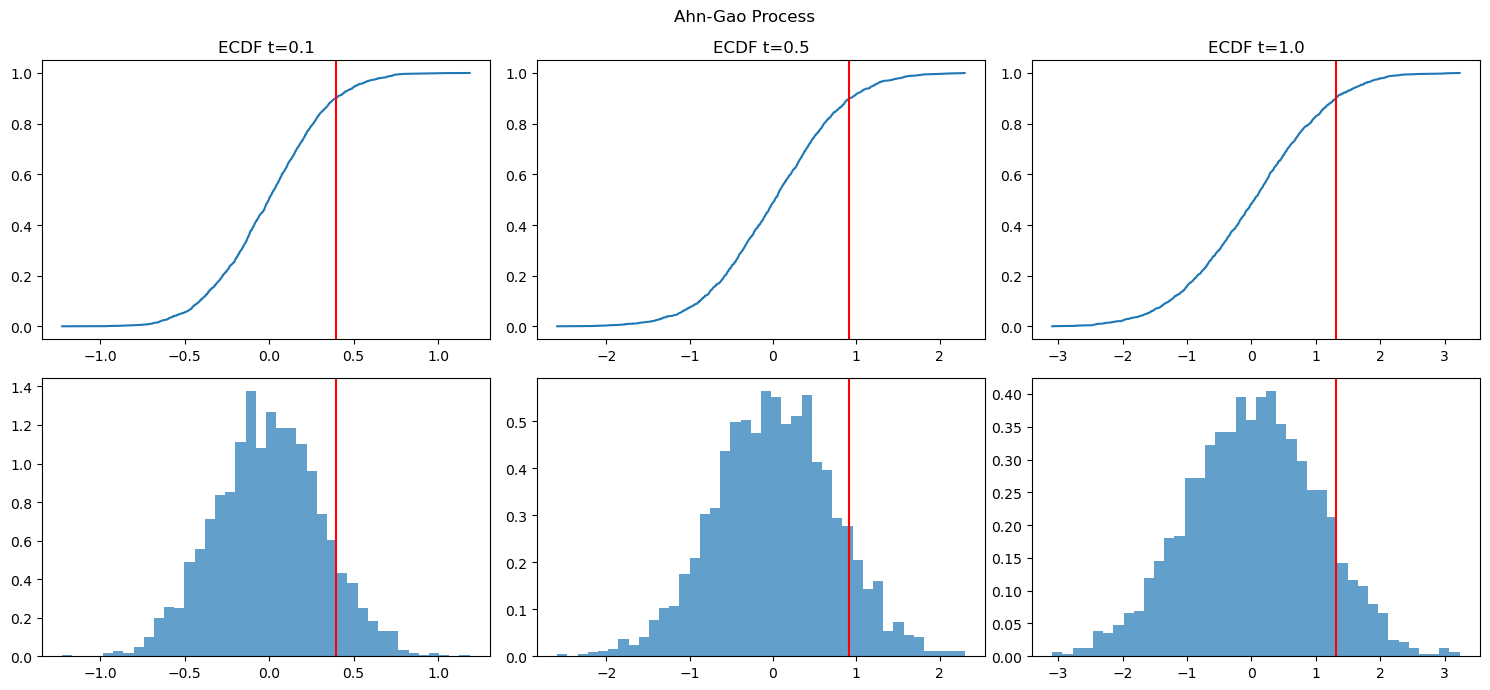

In [ ]:
def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x)+1) / len(x)
    return x, y


def run_process(process_class, params, title):
    T = 1.0
    Nx = 2000
    Nt = 500

    t_points = [0.1, 0.5, 1.0]
    idx_points = [int(t * Nt) for t in t_points]

    dW = np.sqrt(T/Nt) * np.random.randn(Nt, Nx)

    process = process_class(params, T, Nx, Nt)

    _, X = process.ExactSolution(dW)

    fig, axes = plt.subplots(2, 3, figsize=(15, 7))

    fig.suptitle(title)

    for i, (t, idx) in enumerate(zip(t_points, idx_points)):
        sample = X[idx]

        # ECDF
        x_ecdf, y_ecdf = ecdf(sample)
        axes[0, i].plot(x_ecdf, y_ecdf)
        axes[0, i].set_title(f"ECDF t={t}")

        # PDF
        axes[1, i].hist(sample, bins=40, density=True, alpha=0.7)
        q90 = np.quantile(sample, 0.9)

        axes[0, i].axvline(q90, color='r')
        axes[1, i].axvline(q90, color='r')

    plt.tight_layout()
    plt.show()
run_process(
    PearsonProcess,
    params=[2.0, 1.0, 0.5],
    title="Pearson Process"
)

run_process(
    JacobiProcess,
    params=[2.0, 0.5, 0.3],
    title="Jacobi Process"
)

run_process(
    RadialOUProcess,
    params=[1.5, 1.0, 0.3, 3],
    title="Radial OU Process"
)

run_process(
    AhnGaoProcess,
    params=[2.0, 1.0, 0.4],
    title="Ahn-Gao Process"
)

## Выводы по моделированию экзотических стохастических процессов

Проведённое моделирование показывает, что различные стохастические процессы существенно отличаются по структуре распределений и их эволюции во времени. Анализ ECDF, плотностей (histogram) и 90%-квантилей позволяет выделить характерные особенности каждой модели.

**Pearson process** демонстрирует поведение, близкое к гауссовскому распределению с выраженным эффектом возврата к среднему. Со временем распределение стабилизируется, что указывает на наличие стационарного режима и устойчивой динамики вокруг среднего уровня.

**Jacobi process** ограничен на отрезке \([0,1]\), поэтому его распределение всегда остаётся компактным. В зависимости от времени наблюдается перераспределение массы вероятности внутри интервала, при этом форма плотности может быть асимметричной. Это отражает влияние граничных условий на динамику процесса.

**Radial OU process** характеризуется строгой положительностью и концентрацией распределения вокруг некоторого устойчивого радиуса. С течением времени наблюдается усиление концентрации, что соответствует эффекту радиального возврата к среднему состоянию многомерного OU-процесса.

**Ahn–Gao model** обладает наиболее сложной структурой распределения среди рассмотренных процессов. Нелинейная зависимость дисперсии приводит к асимметричным распределениям и более выраженным хвостам, что делает процесс менее предсказуемым и более “размазанным” по сравнению с классическими моделями.

Анализ 90%-квантиля показывает, что для всех процессов характерна его временная динамика, отражающая изменение верхних хвостов распределения. У стационарных процессов квантиль стремится к стабилизации, тогда как у нелинейных моделей может продолжать изменяться.

В целом, результаты подтверждают, что структура стохастического диффузионного члена и ограничения области определения существенно влияют на форму распределений и их эволюцию во времени.


Задача 5.
1. Сгенерируйте по 100 траекторий для процессов со следующими параметрами:  
   - OU: $θ = (1.0, 1.0, 0.5)$,  
   - CIR: $θ = (0.4, 0.3, 0.2)$,
   
   $X_0 = 0.5$, $T = 1$, $Nt = 300$, $Nx = 100$.

2. Для каждого процесса вычислите теоретическое стационарное распределение: OU (нормальное распределение), CIR (гамма-распределение) и постройте гистограммы значений процесса в момент $t = T$ (конечное состояние) для всех траекторий и наложите на них график теоретической плотности.

3. Для процессов вычислите условное среднее и дисперсию по теоретическим формулам: OU (условное распределение — нормальное), CIR условное распределение — нецентральное хи-квадрат.   

4. Постройте графики условного среднего $E[X_t | X_0]$ и условной дисперсии $Var[X_t | X_0]$ на интервале $[0, T]$.

5. Вычислите выборочное среднее и дисперсию по всем траекториям в моменты времени: $t = 0.1$, $t = 0.5$, $t = 1.0$. Сравните с теоретическими значениями и прокомментируйте точность моделирования.

6. Постройте панели графиков (по одной для каждого процесса):
     - Верхний график: 10 случайных траекторий.  
     - Средний график: гистограмма конечных состояний с наложенной теоретической плотностью.  
     - Нижний график: условное среднее и дисперсия как функции времени.  

7. Сделайте выводы.

OU process:
t=0.1
Sample mean: 0.5391644275908927
Theoretical mean: 0.5475812909820202
Sample var: 0.023529446384590248
Theoretical var: 0.022658655865252272

t=0.5
Sample mean: 0.7004146830730841
Theoretical mean: 0.6967346701436833
Sample var: 0.0751379709939778
Theoretical var: 0.07901506985356971

t=1.0
Sample mean: 0.8616136829429917
Theoretical mean: 0.8160602794142788
Sample var: 0.1002489546430724
Theoretical var: 0.10808308959542341

CIR process:
t=0.1
Sample mean: 0.5238379486021493
Theoretical mean: 0.5246287220429099
Sample var: 0.001702747999916626
Theoretical var: 0.0019897081298157317

t=0.5
Sample mean: 0.6075689967346847
Theoretical mean: 0.6160766863124518
Sample var: 0.010611478717254598
Theoretical var: 0.009717296412365087

t=1.0
Sample mean: 0.7085856280198501
Theoretical mean: 0.7159848160985685
Sample var: 0.021162402263922863
Theoretical var: 0.018771567393009718



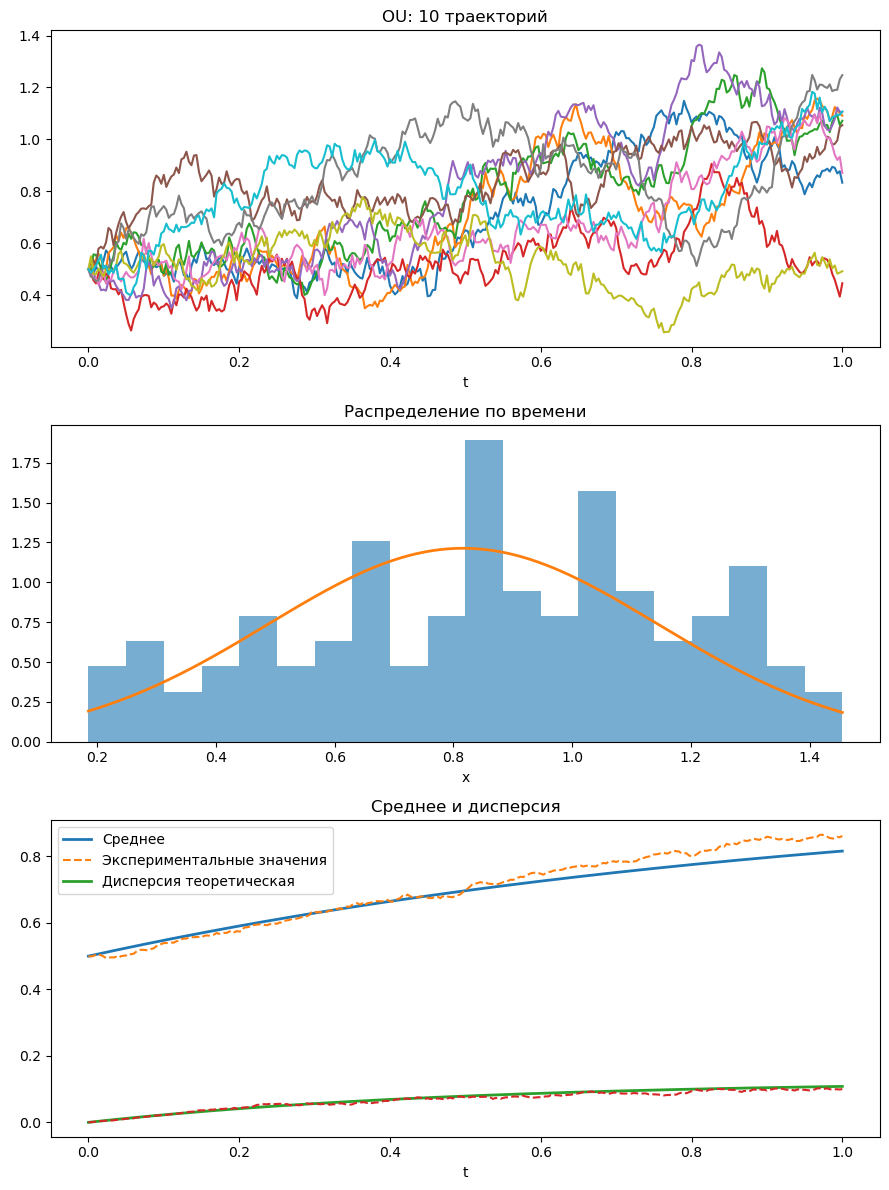

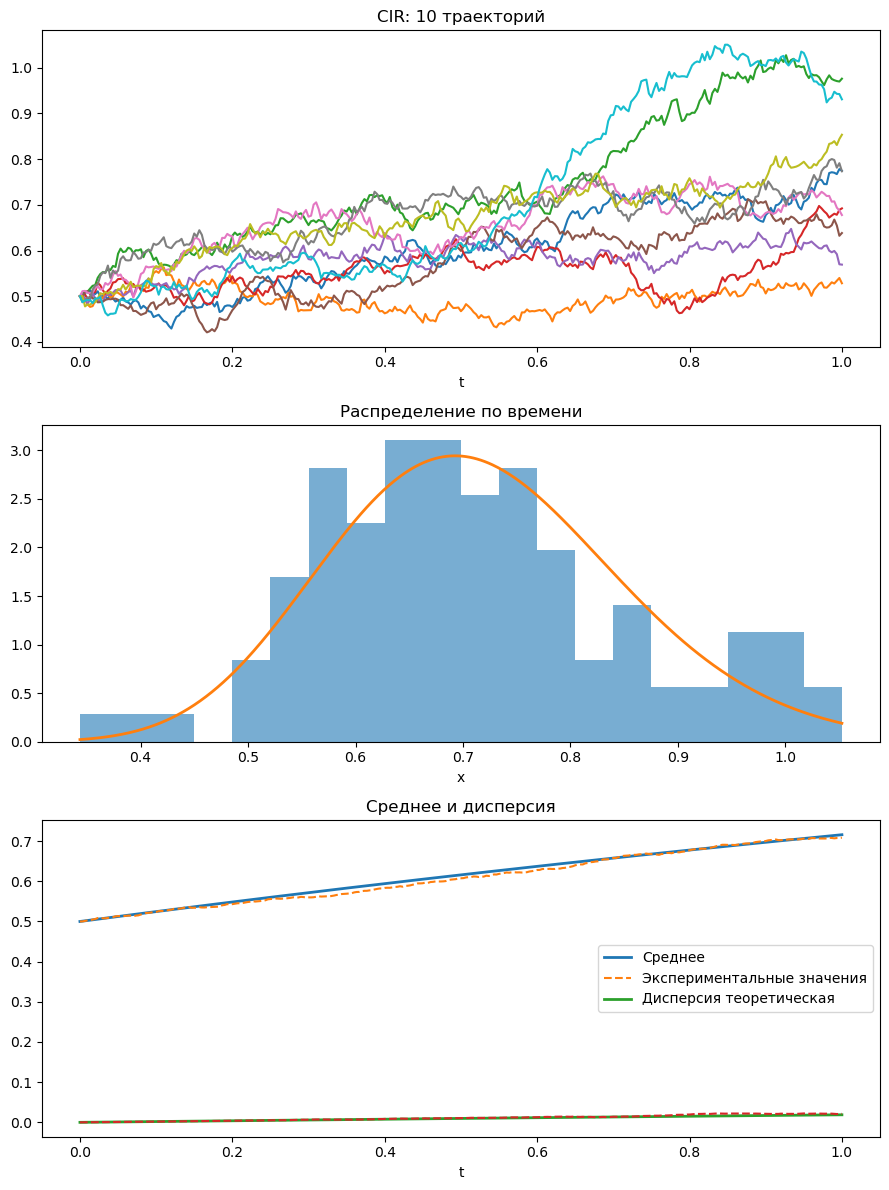

In [ ]:
from scipy.stats import norm, gamma, ncx2

#np.random.seed(42)
T = 1
Nt = 300
Nx = 100
X0 = 0.5

t_grid = np.linspace(0, T, Nt + 1)
dt = T / Nt

ou_params = [1.0, 1.0, 0.5]
ou = OUprocess(ou_params, T, Nx, Nt, init_state=X0*np.ones(Nx))
t_ou, x_ou = ou.PathGenerator()

cir_params = [0.4, 0.3, 0.2]
cir = CIRprocess(cir_params, T, Nx, Nt, init_state=X0*np.ones(Nx))
t_cir, x_cir = cir.PathGenerator()

theta, mu, sigma = ou_params
ou_stat_mean = mu
ou_stat_var = sigma**2 / (2*theta)

theta1, theta2, theta3 = cir_params
kappa = theta2
theta_long = theta1 / theta2
sigma_cir = theta3

shape = 2*kappa*theta_long / sigma_cir**2
scale = sigma_cir**2 / (2*kappa)

def ou_mean(t):
    return mu + (X0 - mu)*np.exp(-theta*t)

def ou_var(t):
    return sigma**2/(2*theta)*(1 - np.exp(-2*theta*t))

def cir_mean(t):
    return X0*np.exp(-kappa*t) + theta_long*(1 - np.exp(-kappa*t))

def cir_var(t):
    return (X0*sigma_cir**2*np.exp(-kappa*t)/kappa)*(1 - np.exp(-kappa*t)) + \
           (theta_long*sigma_cir**2/(2*kappa))*(1 - np.exp(-kappa*t))**2

check_times = [0.1, 0.5, 1.0]

indices = [np.argmin(np.abs(t_grid - t)) for t in check_times]

print("OU process:")
for t, idx in zip(check_times, indices):
    print(f"t={t}")
    print("Sample mean:", np.mean(x_ou[idx]))
    print("Theoretical mean:", ou_mean(t))
    print("Sample var:", np.var(x_ou[idx]))
    print("Theoretical var:", ou_var(t))
    print()

print("CIR process:")
for t, idx in zip(check_times, indices):
    print(f"t={t}")
    print("Sample mean:", np.mean(x_cir[idx]))
    print("Theoretical mean:", cir_mean(t))
    print("Sample var:", np.var(x_cir[idx]))
    print("Theoretical var:", cir_var(t))
    print()


def plot_panel(process_name, t, x):
    
    fig, axs = plt.subplots(3, 1, figsize=(9, 12))
    idx_paths = np.random.choice(Nx, 10, replace=False)
    for i in idx_paths:
        axs[0].plot(t, x[:, i])
    axs[0].set_title(f"{process_name}: 10 траекторий")
    axs[0].set_xlabel("t")

    axs[1].hist(x[-1], bins=20, density=True, alpha=0.6)

    x_vals = np.linspace(np.min(x[-1]), np.max(x[-1]), 400)

    if process_name == "OU":
        mT = ou_mean(T)
        vT = ou_var(T)
        pdf_vals = norm.pdf(x_vals, mT, np.sqrt(vT))
        axs[1].plot(x_vals, pdf_vals, linewidth=2)

    elif process_name == "CIR":
        c = 2*kappa/(sigma_cir**2*(1 - np.exp(-kappa*T)))
        u = c*X0*np.exp(-kappa*T)
        d = 4*kappa*theta_long/sigma_cir**2
        pdf_vals = 2*c * ncx2.pdf(2*c*x_vals, d, 2*u)
        axs[1].plot(x_vals, pdf_vals, linewidth=2)

    axs[1].set_title("Распределение по времени")
    axs[1].set_xlabel("x")
    sample_mean = np.mean(x, axis=1)
    sample_var = np.var(x, axis=1)

    if process_name == "OU":
        theor_mean = ou_mean(t)
        theor_var = ou_var(t)
    else:
        theor_mean = cir_mean(t)
        theor_var = cir_var(t)

    axs[2].plot(t, theor_mean, label="Среднее", linewidth=2)
    axs[2].plot(t, sample_mean, "--", label="Экспериментальные значения")

    axs[2].plot(t, theor_var, label="Дисперсия теоретическая", linewidth=2)
    axs[2].plot(t, sample_var, "--", label="")

    axs[2].set_title("Среднее и дисперсия")
    axs[2].set_xlabel("t")
    axs[2].legend()

    plt.tight_layout()
    plt.show()
plot_panel("OU", t_ou, x_ou)
plot_panel("CIR", t_cir, x_cir)

## выводы

- Для OU процесса численные результаты хорошо совпадают с теоретическими: гистограмма конечных значений соответствует нормальной плотности, выборочные среднее и дисперсия близки к аналитическим формулам.  
- Процесс демонстрирует выраженную возвратность к среднему и быстро приближается к стационарному режиму.  
- Для CIR процесса распределение при T = 1 корректно воспроизводит асимметричную форму (нецентральное χ²).  
- Выборочное среднее совпадает с теоретическим, дисперсия имеет небольшие отклонения из-за конечного числа траекторий.  
- В целом моделирование подтверждает теоретические свойства обоих процессов.